### Processing the CSV file: `/content/adult_with_headers (1).csv`

In [1]:
import pandas as pd

csv_file_path = '/content/adult_with_headers (1).csv'
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded '{csv_file_path}'. First 5 rows:")
display(df.head())

Successfully loaded '/content/adult_with_headers (1).csv'. First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Processing the DOCX file: `/content/Data Trasformation.docx`

In [2]:
# Install the python-docx library to read .docx files
%pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.7 MB/s eta 0:00:00


In [3]:
from docx import Document

docx_file_path = '/content/Data Trasformation.docx'
document = Document(docx_file_path)

print(f"Successfully loaded '{docx_file_path}'. Content (first 5 paragraphs):")
for i, para in enumerate(document.paragraphs):
    if i < 5:
        print(para.text)
    else:
        break

Successfully loaded '/content/Data Trasformation.docx'. Content (first 5 paragraphs):
Data Preprocessing and Feature Engineering in Machine Learning
Objective:
This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.
Dataset:
Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# ==========================================
# 1. DATA LOADING AND EXPLORATION
# ==========================================
print("="*60)
print("TASK 1: DATA EXPLORATION AND MISSING VALUES IMPUTATION")
print("="*60)

# Load dataset
df = pd.read_csv('adult_with_headers (1).csv')

# Clean white spaces from string column fields
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Numerical Feature Distributions Summary ---")
print(df.describe().T)

# Identify census data missing values flagged as '?'
print("\n--- Identifying Hidden Missing Values ('?') ---")
missing_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        zeros_q = (df[col] == '?').sum()
        if zeros_q > 0:
            missing_counts[col] = zeros_q
            print(f"Feature '{col}': found {zeros_q} entries containing '?'")

# Best Practice Imputation: Replacing '?' with the mode (most frequent value) of each column
df_clean = df.copy()
for col in missing_counts.keys():
    mode_value = df_clean[df_clean[col] != '?'][col].mode()[0]
    df_clean[col] = df_clean[col].replace('?', mode_value)

print("\nMissing values imputed using mode replacement.")

# ==========================================
# 2. NUMERICAL FEATURE SCALING
# ==========================================
print("\n" + "="*60)
print("TASK 2: NUMERICAL SCALING (STANDARD VS MIN-MAX)")
print("="*60)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical variables identified for scaling: {list(numerical_cols)}")

# Standard Scaling (Z-score)
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df_clean[numerical_cols]), columns=numerical_cols)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df_clean[numerical_cols]), columns=numerical_cols)

print("\nSample Standard Scaled Outputs (First 2 rows):")
print(df_standard.head(2))
print("\nSample Min-Max Scaled Outputs (First 2 rows):")
print(df_minmax.head(2))

# ==========================================
# 3. CATEGORICAL VARIABLE ENCODING
# ==========================================
print("\n" + "="*60)
print("TASK 3: CATEGORICAL VARIABLE ENCODING")
print("="*60)

categorical_cols = df_clean.select_dtypes(include=['object']).columns.drop('income')
print("Categorical Feature Profile:")
for col in categorical_cols:
    print(f"  - {col}: {df_clean[col].nunique()} categories")

# Rules applied according to criteria:
# One-Hot Encoding if categories < 5 (e.g., sex, race)
# Label Encoding if categories >= 5 (e.g., workclass, education, occupation, marital_status, relationship, native_country)

df_encoded = df_clean.copy()
one_hot_targets = []
label_encode_targets = []

for col in categorical_cols:
    if df_clean[col].nunique() < 5:
        one_hot_targets.append(col)
    else:
        label_encode_targets.append(col)

print(f"\nTargeting for One-Hot Encoding (<5 categories): {one_hot_targets}")
print(f"Targeting for Label Encoding (>=5 categories): {label_encode_targets}")

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_targets, drop_first=True)

# Perform Label Encoding
label_encoders = {}
for col in label_encode_targets:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(f"\nFinal Preprocessed Data Shape (post-encoding): {df_encoded.shape}")

# ==========================================
# 4. FEATURE ENGINEERING & SKEWNESS TRANSFORMATION
# ==========================================
print("\n" + "="*60)
print("TASK 4: FEATURE ENGINEERING AND TRANSFORMATIONS")
print("="*60)

# Check Skewness of numerical features
print("Feature Skewness Metrics:")
print(df_clean[numerical_cols].skew())

# Metric Transformation: Log Transformation on heavily skewed 'capital_gain'
# log1p is used to handle 0 values safely: log(x + 1)
df_encoded['capital_gain_log'] = np.log1p(df_encoded['capital_gain'])
print("\n--- Justification for Log Transformation ---")
print(f"Original 'capital_gain' skewness: {df_clean['capital_gain'].skew():.4f}")
print(f"Log Transformed 'capital_gain_log' skewness: {df_encoded['capital_gain_log'].skew():.4f}")

# Engineering Feature 1: Hours per year (hours_per_week * 52)
df_encoded['hours_per_year'] = df_encoded['hours_per_week'] * 52

# Engineering Feature 2: Capital Balance Net Flow (capital_gain - capital_loss)
df_encoded['net_capital_flow'] = df_encoded['capital_gain'] - df_encoded['capital_loss']

print("\nSuccessfully engineered new structural features:")
print("1. 'hours_per_year' (Total annual committed work hours)")
print("2. 'net_capital_flow' (Net continuous investment balance return)")

# ==========================================
# 5. ADVANCED DETECTION: ISOLATION FOREST OUTLIERS
# ==========================================
print("\n" + "="*60)
print("TASK 5: ADVANCED OUTLIER DETECTION VIA ISOLATION FOREST")
print("="*60)

# Isolate features matrix for anomaly detection (ignoring target string feature 'income')
X_iso = df_encoded.drop(columns=['income'])

iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
outlier_preds = iso_forest.fit_predict(X_iso)

# -1 represents an outlier, 1 represents normal data
df_encoded['is_outlier'] = outlier_preds
outliers_count = (df_encoded['is_outlier'] == -1).sum()

print(f"Total rows flagged as multivariate outliers (at 2% contamination threshold): {outliers_count}")
print(f"Clean rows kept for training matrix structures: {(df_encoded['is_outlier'] == 1).sum()}")
print("="*60)

TASK 1: DATA EXPLORATION AND MISSING VALUES IMPUTATION
Dataset Shape: 32561 rows, 15 columns

--- Numerical Feature Distributions Summary ---
                  count           mean            std      min       25%  \
age             32561.0      38.581647      13.640433     17.0      28.0   
fnlwgt          32561.0  189778.366512  105549.977697  12285.0  117827.0   
education_num   32561.0      10.080679       2.572720      1.0       9.0   
capital_gain    32561.0    1077.648844    7385.292085      0.0       0.0   
capital_loss    32561.0      87.303830     402.960219      0.0       0.0   
hours_per_week  32561.0      40.437456      12.347429      1.0      40.0   

                     50%       75%        max  
age                 37.0      48.0       90.0  
fnlwgt          178356.0  237051.0  1484705.0  
education_num       10.0      12.0       16.0  
capital_gain         0.0       0.0    99999.0  
capital_loss         0.0       0.0     4356.0  
hours_per_week      40.0      45.0   

### Income Distribution Visualization

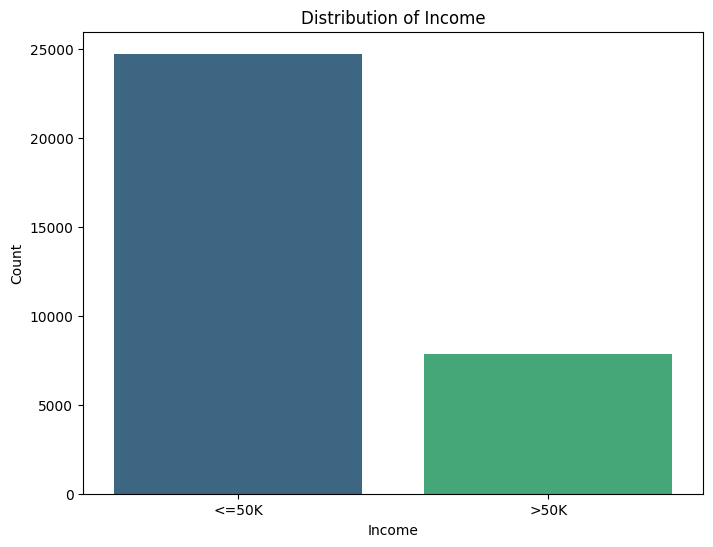

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='income', data=df_encoded, hue='income', palette='viridis', legend=False)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

### Percentage of Each Income Category

In [7]:
income_percentages = df_encoded['income'].value_counts(normalize=True) * 100
print("Percentage of each income category:")
display(income_percentages)

Percentage of each income category:


,proportion
income,
<=50K,75.919044
>50K,24.080956


### Splitting Data into Training and Testing Sets

In [8]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (26048, 18)
X_test shape: (6513, 18)
y_train shape: (26048,)
y_test shape: (6513,)
